In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import quantstats as qs
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('../src'))

# Import all our pipeline functions, including the new fundamentals and ROE
from data_loader import download_price_data, clean_price_data, download_fundamentals
from factors import compute_momentum, compute_volatility, compute_roe, compute_cross_sectional_zscore
from signals import build_composite_signal
from backtest import generate_target_weights, calculate_portfolio_performance

qs.extend_pandas()
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [2]:
# 1. Define Universe & Dates
mvp_universe = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'BRK-B', 'JPM', 'JNJ',
    'V', 'PG', 'XOM', 'HD', 'CVX', 'MA', 'BAC', 'ABBV', 'PFE', 'AVGO', 
    'COST', 'DIS', 'KO', 'PEP', 'CSCO', 'WMT', 'TMO', 'MCD', 'ABT', 'CRM'
]
start_date = '2021-01-01'
end_date = '2026-12-31'

# 2. Load Prices
prices_raw, _ = download_price_data(mvp_universe, start_date, end_date)
prices = clean_price_data(prices_raw)
daily_returns = prices.pct_change(fill_method=None).dropna()

# 3. Load Fundamentals (This might take a minute as it queries yfinance for each ticker)
print("Fetching fundamentals for Quality factor...")
fundamentals = download_fundamentals(prices.columns)
print("Data ingestion complete.")

2026-03-27 18:40:47,957 - INFO - Downloading data for 30 tickers from 2021-01-01 to 2026-12-31...
2026-03-27 18:40:49,682 - INFO - Shape before cleaning: (1314, 30)
2026-03-27 18:40:49,686 - INFO - Shape after cleaning: (1314, 30) (0 dropped)
2026-03-27 18:40:49,688 - INFO - Fetching fundamentals for 30 tickers...


Fetching fundamentals for Quality factor...
Data ingestion complete.


In [3]:
# 1. Compute Raw Factors
raw_momentum = compute_momentum(prices).dropna(how='all')
raw_volatility = compute_volatility(daily_returns).dropna(how='all')

# Compute ROE (incorporating the 90-day lag to prevent look-ahead bias)
raw_roe = compute_roe(fundamentals, prices.index).dropna(how='all')

# 2. Standardize (Z-Score)
z_momentum = compute_cross_sectional_zscore(raw_momentum)
z_low_vol = -compute_cross_sectional_zscore(raw_volatility) # Inverted!
z_quality = compute_cross_sectional_zscore(raw_roe)

# 3. Build the Composite Signal (40% Mom, 30% Vol, 30% Quality)
composite_scores = build_composite_signal(
    z_momentum, z_low_vol, z_quality, 
    weights={'mom': 0.40, 'vol': 0.30, 'qual': 0.30}
)

# 4. Generate Weights (Top 10 Stocks, Equal Weight)
target_weights = generate_target_weights(composite_scores, top_n=10)

2026-03-27 18:41:10,874 - INFO - Computing momentum (lookback=252, skip=21)...
2026-03-27 18:41:10,912 - INFO - Computing annualized rolling volatility (window=252)...
2026-03-27 18:41:10,975 - INFO - Computing Quality factor (ROE)...
2026-03-27 18:41:11,034 - INFO - Computing cross-sectional z-scores...
2026-03-27 18:41:11,044 - INFO - Computing cross-sectional z-scores...
2026-03-27 18:41:11,050 - INFO - Computing cross-sectional z-scores...
2026-03-27 18:41:11,068 - INFO - Building composite signal with weights: {'mom': 0.4, 'vol': 0.3, 'qual': 0.3}
2026-03-27 18:41:11,091 - INFO - Generating monthly target weights for top 10 stocks...


In [4]:
# 1. Calculate Gross and Net returns
gross_returns, net_returns = calculate_portfolio_performance(
    target_weights, daily_returns, cost_bps=20
)

# 2. Fetch Benchmark (SPY)
benchmark_data = yf.download('SPY', start=net_returns.index[0], end=end_date, auto_adjust=True, progress=False)
benchmark_returns = benchmark_data['Close'].pct_change().dropna()
benchmark_returns.name = "S&P 500 (SPY)"

# 3. CRITICAL FIX: Align all three series together so they have the exact same index/length
# This creates a single DataFrame and drops any rows where ANY of the three are missing
comparison_df = pd.concat([gross_returns, net_returns, benchmark_returns], axis=1).dropna()

# Rename columns for clarity
comparison_df.columns = ['Gross', 'Net', 'Benchmark']

# Extract the aligned series back out
gross_aligned = comparison_df['Gross']
net_aligned = comparison_df['Net']
benchmark_aligned = comparison_df['Benchmark']

2026-03-27 18:41:14,871 - INFO - Calculating performance with 20 bps transaction cost...


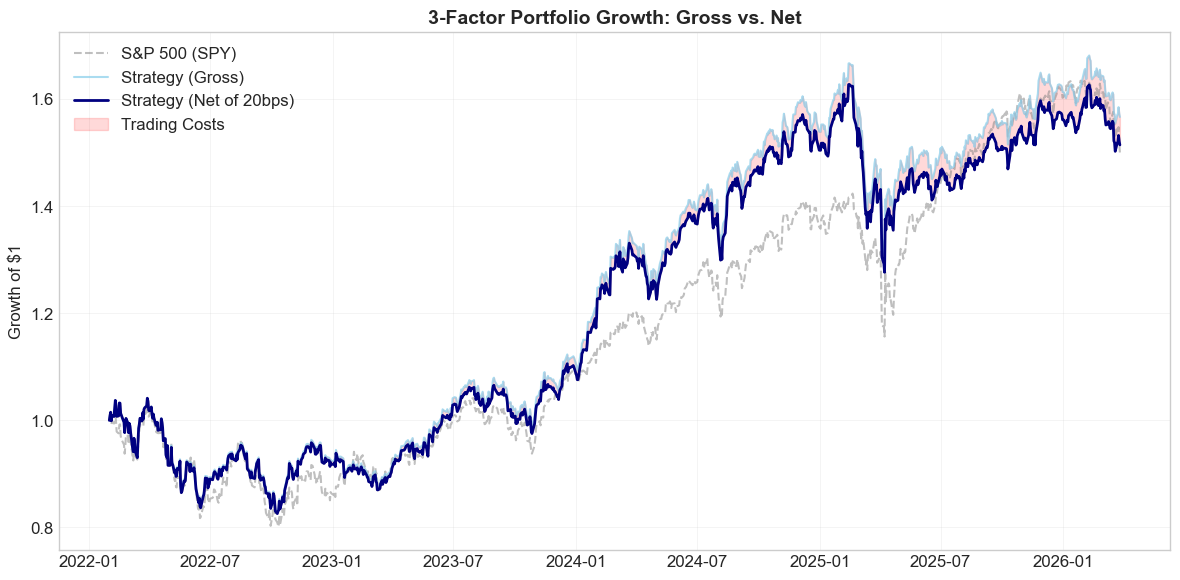


Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Benchmark    Strategy
-------------------  -----------  ----------
Start Period         2022-02-01   2022-02-01
End Period           2026-03-27   2026-03-27
Risk-Free Rate       0.0%         0.0%
Time in Market       100.0%       100.0%

Cumulative Return    50.02%       51.43%
CAGR﹪               10.31%       10.56%

Sharpe               0.64         0.69
Prob. Sharpe Ratio   90.5%        91.9%
Sortino              0.93         1.0
Sortino/√2           0.65         0.71
Omega                1.12         1.13

Max Drawdown         -22.09%      -21.56%
Max DD Date          2022-10-12   2025-04-08
Max DD Period Start  2022-03-30   2025-02-18
Max DD Period End    2023-07-17   2026-03-27
Longest DD Days      475          470

Gain/Pain Ratio      0.12         0.13
Gain/Pain (1M)       0.65         0.71

Payoff Rat

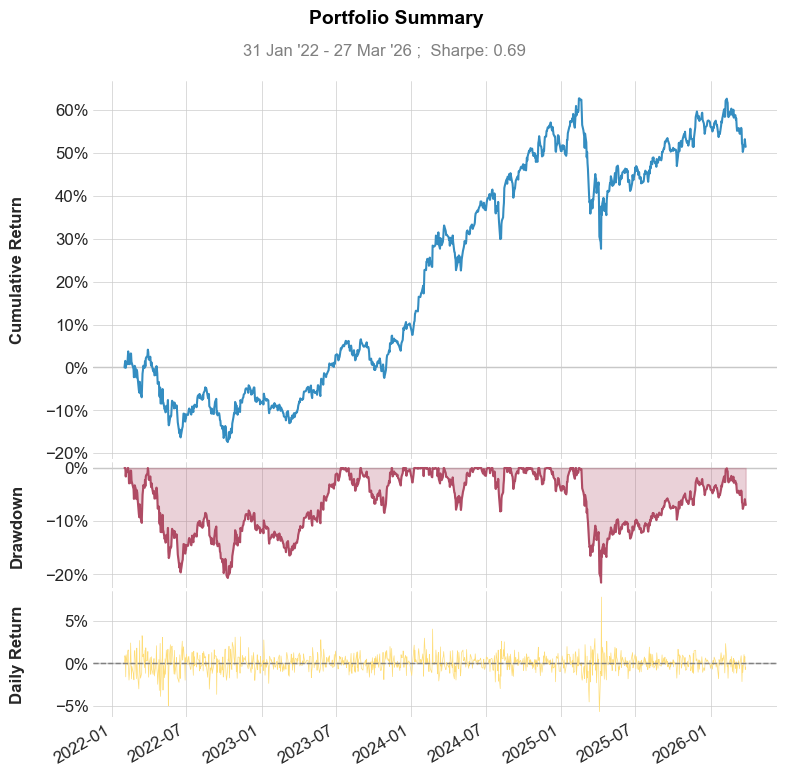

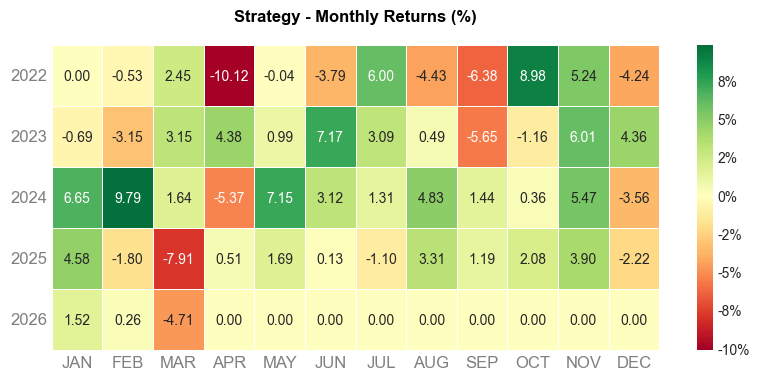

In [5]:
# 1. Calculate Cumulative Growth starting from 1.0
def get_cumulative(series):
    # Add a 0 return at the start to represent the initial $1.00 investment
    start_date = series.index[0] - pd.Timedelta(days=1)
    combined = pd.concat([pd.Series([0], index=[start_date]), series])
    return (1 + combined).cumprod()

cum_gross = get_cumulative(gross_aligned)
cum_net = get_cumulative(net_aligned)
cum_bench = get_cumulative(benchmark_aligned)

# 2. Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the lines
ax.plot(cum_bench, label='S&P 500 (SPY)', color='gray', alpha=0.5, linestyle='--')
ax.plot(cum_gross, label='Strategy (Gross)', color='skyblue', alpha=0.7)
ax.plot(cum_net, label='Strategy (Net of 20bps)', color='navy', linewidth=2)

# Fill the gap (This will now work because indices match perfectly)
ax.fill_between(cum_gross.index, cum_net, cum_gross, color='red', alpha=0.15, label='Trading Costs')

# Formatting
ax.set_title("3-Factor Portfolio Growth: Gross vs. Net", fontsize=14, fontweight='bold')
ax.set_ylabel("Growth of $1", fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Run QuantStats on the aligned net returns
qs.reports.basic(net_aligned, benchmark=benchmark_aligned)

2026-03-27 18:41:48,581 - INFO - Downloading data for 30 tickers from 2018-01-01 to 2023-12-31...
2026-03-27 18:41:50,069 - INFO - Shape before cleaning: (1509, 30)
2026-03-27 18:41:50,078 - INFO - Shape after cleaning: (1509, 30) (0 dropped)
2026-03-27 18:41:50,080 - INFO - Fetching fundamentals for 30 tickers...
2026-03-27 18:42:09,233 - INFO - Computing momentum (lookback=252, skip=21)...
2026-03-27 18:42:09,238 - INFO - Computing annualized rolling volatility (window=252)...
2026-03-27 18:42:09,246 - INFO - Computing Quality factor (ROE)...
2026-03-27 18:42:09,269 - INFO - Generating synthetic ESG scores for the universe...
2026-03-27 18:42:09,279 - INFO - Computing cross-sectional z-scores...
2026-03-27 18:42:09,285 - INFO - Computing cross-sectional z-scores...
2026-03-27 18:42:09,288 - INFO - Computing cross-sectional z-scores...
2026-03-27 18:42:09,292 - INFO - Computing cross-sectional z-scores...
2026-03-27 18:42:09,302 - INFO - Building composite signal with weights: {'mom':

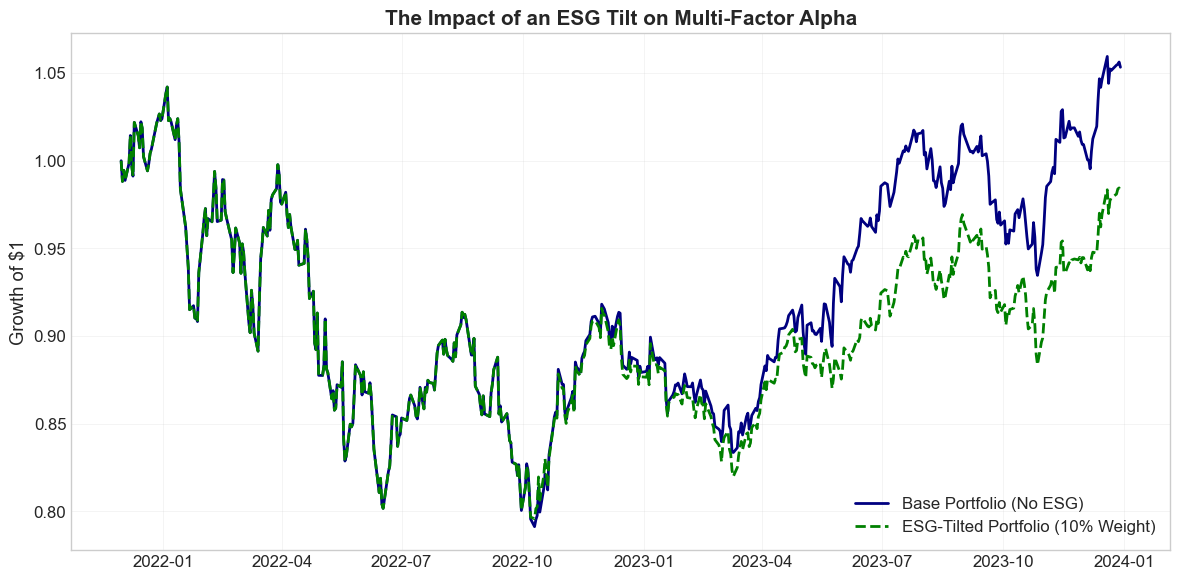

--- ANNUALIZED RETURNS ---
Base Portfolio: 2.53%
ESG Tilted:     -0.85%


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import quantstats as qs

sys.path.append(os.path.abspath('../src'))

from data_loader import download_price_data, clean_price_data, download_fundamentals
from factors import compute_momentum, compute_volatility, compute_roe, compute_synthetic_esg, compute_cross_sectional_zscore
from signals import build_composite_signal
from backtest import generate_target_weights, calculate_portfolio_performance

# 1. Load Data
mvp_universe = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'BRK-B', 'JPM', 'JNJ',
                'V', 'PG', 'XOM', 'HD', 'CVX', 'MA', 'BAC', 'ABBV', 'PFE', 'AVGO', 
                'COST', 'DIS', 'KO', 'PEP', 'CSCO', 'WMT', 'TMO', 'MCD', 'ABT', 'CRM']

prices_raw, _ = download_price_data(mvp_universe, '2018-01-01', '2023-12-31')
prices = clean_price_data(prices_raw)
daily_returns = prices.pct_change(fill_method=None).dropna()
fundamentals = download_fundamentals(prices.columns)

# 2. Compute Raw Factors
raw_mom = compute_momentum(prices).dropna(how='all')
raw_vol = compute_volatility(daily_returns).dropna(how='all')
raw_roe = compute_roe(fundamentals, prices.index).dropna(how='all')
raw_esg = compute_synthetic_esg(prices.columns, prices.index)

# 3. Z-Score All Factors
z_mom = compute_cross_sectional_zscore(raw_mom)
z_vol = -compute_cross_sectional_zscore(raw_vol) # Inverted
z_roe = compute_cross_sectional_zscore(raw_roe)
z_esg = compute_cross_sectional_zscore(raw_esg)

# ==========================================
# MODEL A: Base 3-Factor (No ESG)
# ==========================================
score_base = build_composite_signal(z_mom, z_vol, z_roe, weights={'mom': 0.4, 'vol': 0.3, 'qual': 0.3})
weights_base = generate_target_weights(score_base, top_n=10)
_, net_base = calculate_portfolio_performance(weights_base, daily_returns, cost_bps=20)

# ==========================================
# MODEL B: Tilted 4-Factor (With ESG)
# We sacrifice 5% from Mom and 5% from Qual to give a 10% tilt to ESG
# ==========================================
score_esg = build_composite_signal(z_mom, z_vol, z_roe, z_esg=z_esg, weights={'mom': 0.35, 'vol': 0.30, 'qual': 0.25, 'esg': 0.10})
weights_esg = generate_target_weights(score_esg, top_n=10)
_, net_esg = calculate_portfolio_performance(weights_esg, daily_returns, cost_bps=20)

# ==========================================
# Plotting the Comparison
# ==========================================
comparison_df = pd.concat([net_base, net_esg], axis=1).dropna()
comparison_df.columns = ['Base 3-Factor', 'ESG-Tilted 4-Factor']

# Calculate cumulative returns base 1.0
cum_returns = (1 + comparison_df).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_returns['Base 3-Factor'], label='Base Portfolio (No ESG)', color='navy', linewidth=2)
ax.plot(cum_returns['ESG-Tilted 4-Factor'], label='ESG-Tilted Portfolio (10% Weight)', color='green', linewidth=2, linestyle='--')

ax.set_title("The Impact of an ESG Tilt on Multi-Factor Alpha", fontsize=15, fontweight='bold')
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print quick stats
print("--- ANNUALIZED RETURNS ---")
print(f"Base Portfolio: {qs.stats.cagr(comparison_df['Base 3-Factor']):.2%}")
print(f"ESG Tilted:     {qs.stats.cagr(comparison_df['ESG-Tilted 4-Factor']):.2%}")